Ejercicio 1 — Detección de zonas de entrega

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

In [2]:
# Cargar archivo CSV
df = pd.read_csv('/content/ejercicio_1_zonas_entrega.csv')

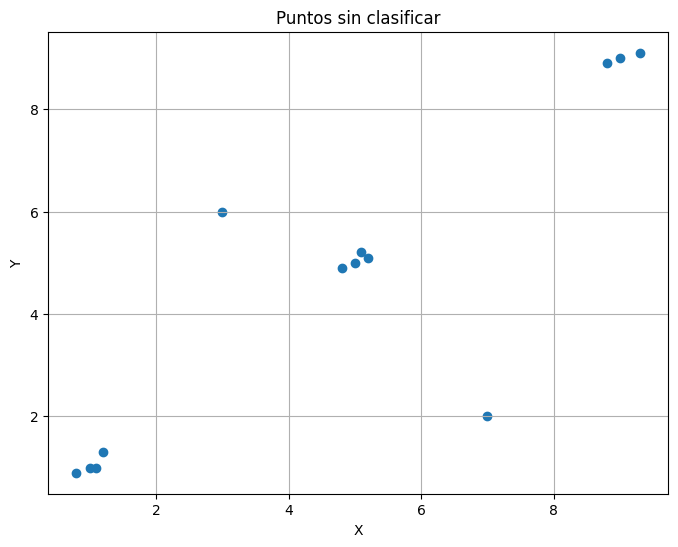

In [3]:
plt.figure(figsize=(8,6))
plt.scatter(df['X'], df['Y'])
plt.title('Puntos sin clasificar')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.show()

In [4]:
#Aplicar DBSCAN
modelo = DBSCAN(eps=0.8, min_samples=3)
clusters = modelo.fit_predict(df[['X', 'Y']])

In [5]:
df['Cluster'] = clusters
print("\nDataFrame con clusters:")
print(df)


DataFrame con clusters:
   Punto    X    Y  Cluster
0     P1  1.0  1.0        0
1     P2  1.2  1.3        0
2     P3  0.8  0.9        0
3     P4  1.1  1.0        0
4     P5  5.0  5.0        1
5     P6  5.2  5.1        1
6     P7  4.8  4.9        1
7     P8  5.1  5.2        1
8     P9  9.0  9.0        2
9    P10  9.3  9.1        2
10   P11  8.8  8.9        2
11   P12  3.0  6.0       -1
12   P13  7.0  2.0       -1


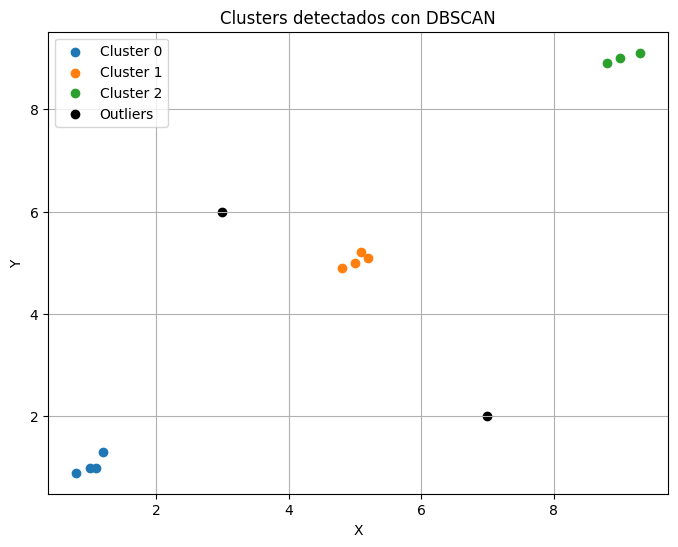

In [6]:
plt.figure(figsize=(8,6))
clusters_unicos = set(clusters)
for cluster in clusters_unicos:
    datos_cluster = df[df['Cluster'] == cluster]
    if cluster == -1:
        plt.scatter(
            datos_cluster['X'],
            datos_cluster['Y'],
            color='black',
            label='Outliers'
        )
    else:
        plt.scatter(
            datos_cluster['X'],
            datos_cluster['Y'],
            label=f'Cluster {cluster}'
        )
plt.title('Clusters detectados con DBSCAN')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

¿Cuántas zonas de entrega identificó el algoritmo?

In [10]:
num_zonas = len(set(clusters)) - (1 if -1 in clusters else 0)
print(f"\nEl algoritmo identifico {num_zonas} zonas de entrega")


El algoritmo identifico 3 zonas de entrega
